# 04 — Avaliação e Explicabilidade (SHAP)

**Objetivo:** Calcular métricas finais (acurácia, F1, ROC-AUC, matriz de confusão)
e usar SHAP para explicar as predições do modelo selecionado.

In [22]:
import sys
sys.path.append('..')

import joblib
import pandas as pd
from pathlib import Path

from src.data_loader import load_breast_cancer_data
from src.preprocessing import split_and_scale
from src.evaluate import evaluate_all_models

df = load_breast_cancer_data()
X_train, X_test, y_train, y_test, scaler = split_and_scale(df)

models_dir = Path("../outputs/models")
modelos_treinados = {
    "logistic_regression": joblib.load(models_dir / "logistic_regression.pkl"),
    "random_forest": joblib.load(models_dir / "random_forest.pkl"),
    "knn": joblib.load(models_dir / "knn.pkl"),
}

print("Modelos carregados:", list(modelos_treinados.keys()))

Modelos carregados: ['logistic_regression', 'random_forest', 'knn']


In [23]:
resultados = evaluate_all_models(modelos_treinados, X_test, y_test)
resultados

,accuracy,precision,recall,f1_score
modelo,,,,
logistic_regression,0.964912,0.975000,0.928571,0.951220
random_forest,0.973684,1.000000,0.928571,0.962963
knn,0.956140,0.974359,0.904762,0.938272


In [24]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from src.models import get_model

X = df.drop(columns=['diagnosis'])
y = (df['diagnosis'] == 'M').astype(int)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados_cv = {}
for nome in ["logistic_regression", "random_forest", "knn"]:
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("modelo", get_model(nome))
    ])
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring="recall")
    resultados_cv[nome] = scores
    print(f"{nome:20s} | Recall médio: {scores.mean():.3f} (+/- {scores.std():.3f}) | folds: {[round(s,3) for s in scores]}")

logistic_regression  | Recall médio: 0.944 (+/- 0.052) | folds: [np.float64(0.977), np.float64(0.86), np.float64(0.905), np.float64(1.0), np.float64(0.976)]
random_forest        | Recall médio: 0.934 (+/- 0.054) | folds: [np.float64(0.977), np.float64(0.86), np.float64(0.881), np.float64(1.0), np.float64(0.952)]
knn                  | Recall médio: 0.925 (+/- 0.046) | folds: [np.float64(0.953), np.float64(0.884), np.float64(0.881), np.float64(1.0), np.float64(0.905)]


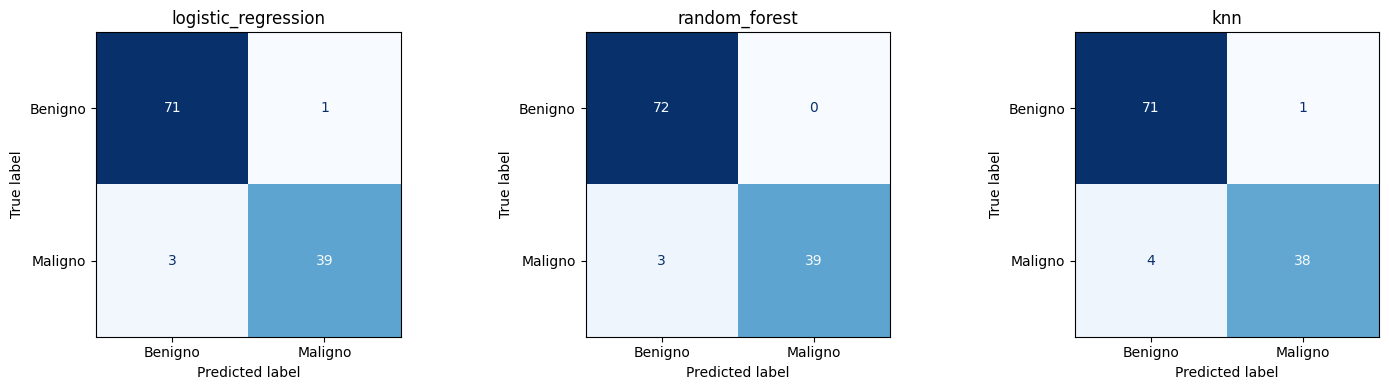

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (nome, modelo) in zip(axes, modelos_treinados.items()):
    ConfusionMatrixDisplay.from_estimator(
        modelo, X_test, y_test,
        display_labels=["Benigno", "Maligno"],
        cmap="Blues", ax=ax, colorbar=False
    )
    ax.set_title(nome)

plt.tight_layout()
plt.show()

In [26]:
import shap

modelo_lr = modelos_treinados["logistic_regression"]

explainer = shap.LinearExplainer(modelo_lr, X_train)
shap_values = explainer(X_test)

print("Shape dos valores SHAP:", shap_values.values.shape)

Background dataset has 455 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=455 when initializing the masker.


Shape dos valores SHAP: (114, 30)


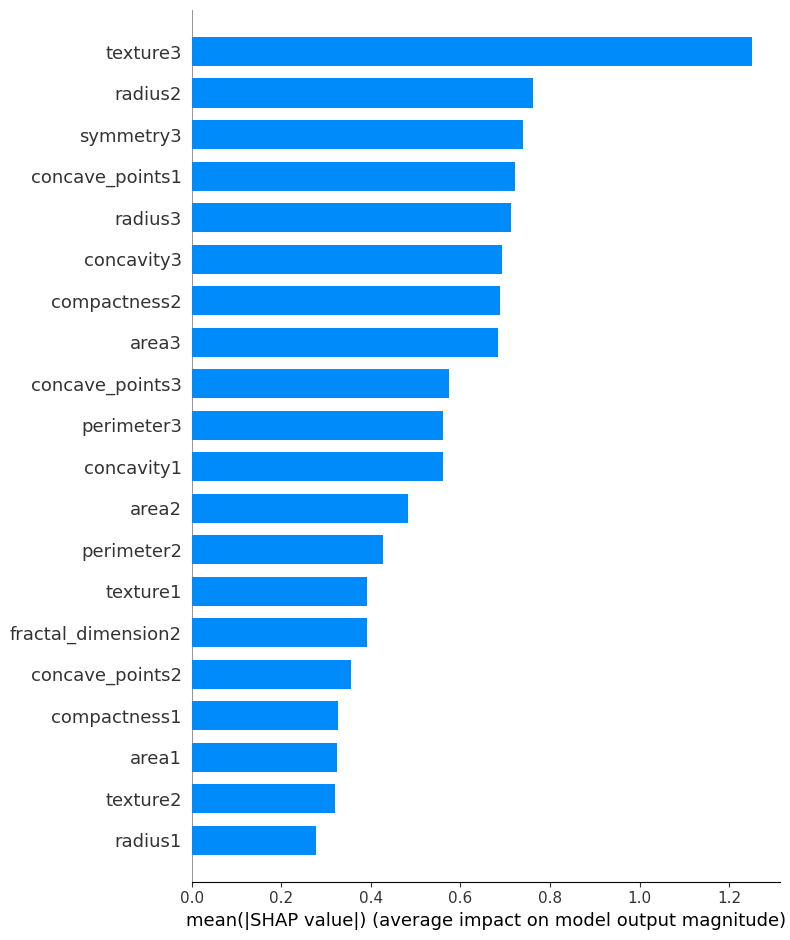

In [27]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

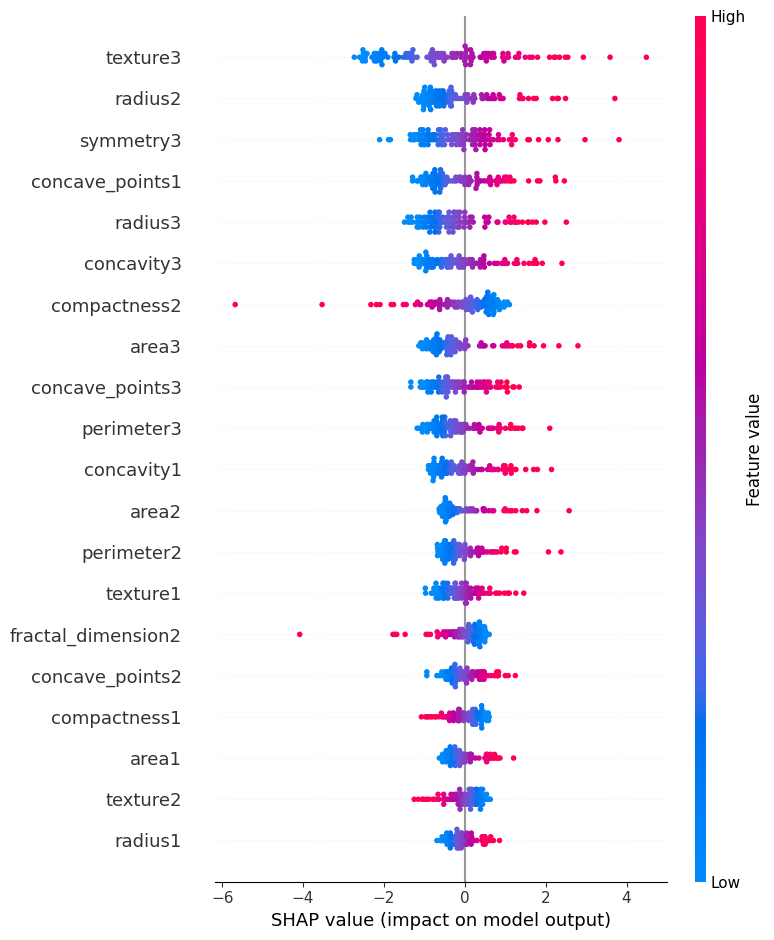

In [28]:
shap.summary_plot(shap_values, X_test)

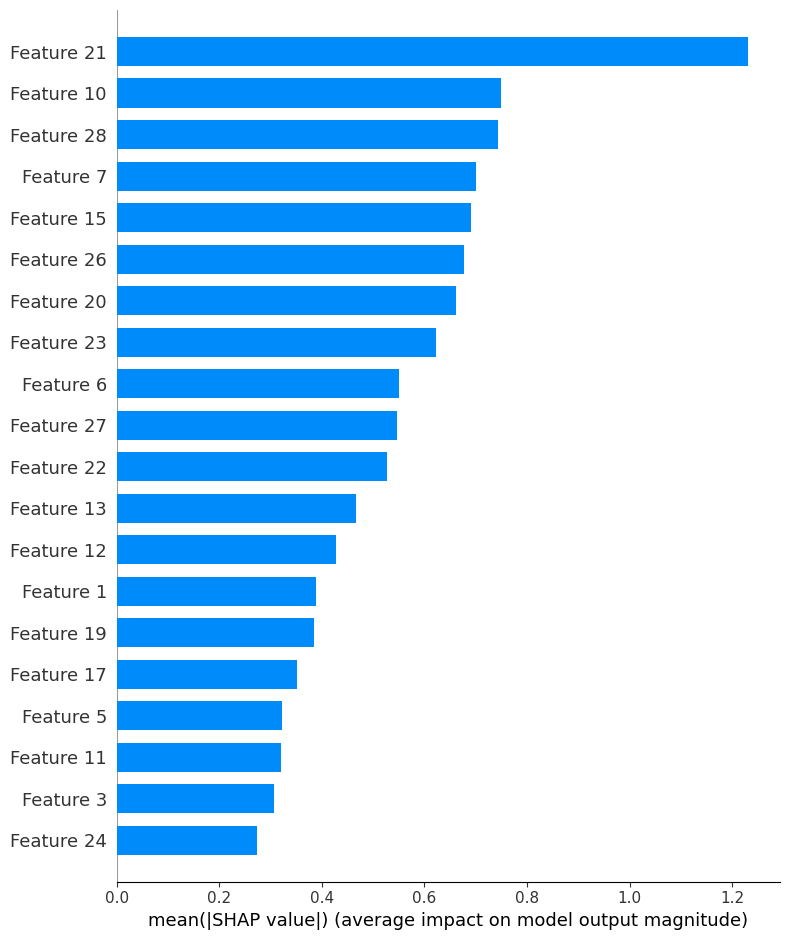

In [29]:
masker = shap.maskers.Independent(X_train.values, max_samples=455)
explainer_lr = shap.LinearExplainer(modelo_lr, masker)
shap_values_lr = explainer_lr(X_test.values)

shap.summary_plot(shap_values_lr, X_test, plot_type="bar")

In [30]:
coefs = pd.Series(modelo_lr.coef_[0], index=X_train.columns)
coefs_ordenados = coefs.reindex(coefs.abs().sort_values(ascending=False).index)
coefs_ordenados.head(15)

texture3              1.434093
radius2               1.233325
symmetry3             1.061264
concave_points1       0.952813
concavity3            0.911406
area2                 0.909029
compactness2         -0.906925
area3                 0.900477
radius3               0.896968
concavity1            0.782298
perimeter2            0.748295
perimeter3            0.723111
concave_points3       0.703999
fractal_dimension2   -0.593876
texture1              0.482219
dtype: float64

In [31]:
df.drop(columns=['diagnosis'])[['radius1', 'radius2', 'radius3', 'texture1', 'texture2', 'texture3']].corr()

,radius1,radius2,radius3,texture1,texture2,texture3
radius1,1.000000,0.679090,0.969539,0.323782,-0.097317,0.297008
radius2,0.679090,1.000000,0.715065,0.275869,0.213247,0.194799
radius3,0.969539,0.715065,1.000000,0.352573,-0.111690,0.359921
texture1,0.323782,0.275869,0.352573,1.000000,0.386358,0.912045
texture2,-0.097317,0.213247,-0.111690,0.386358,1.000000,0.409003
texture3,0.297008,0.194799,0.359921,0.912045,0.409003,1.000000


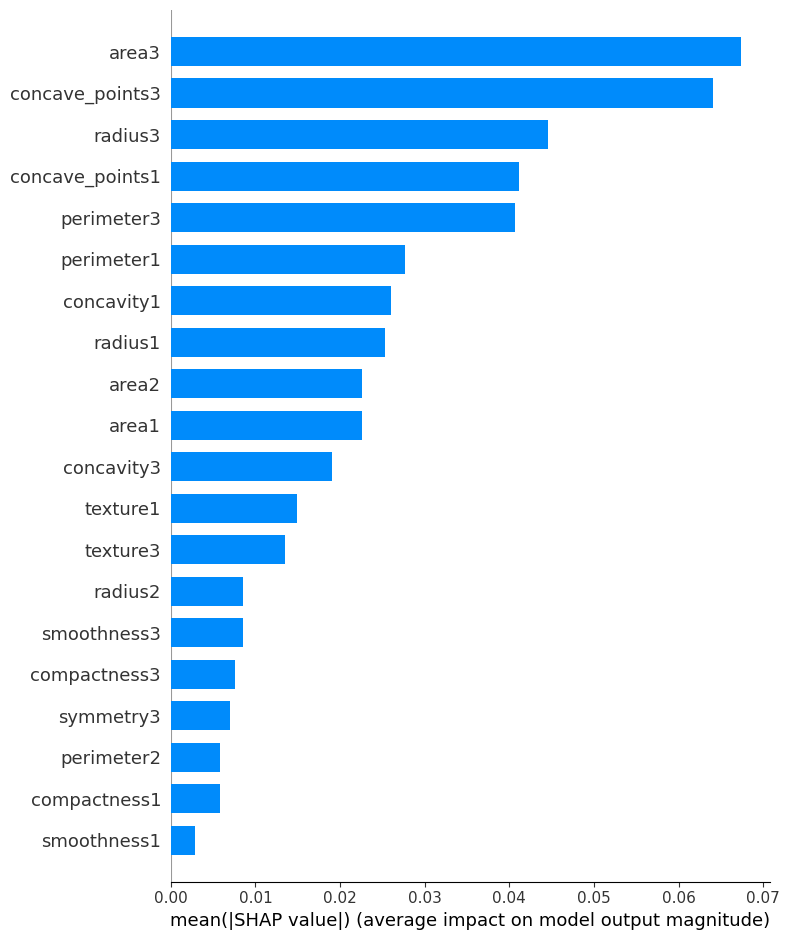

In [32]:
modelo_rf = modelos_treinados["random_forest"]

explainer_rf = shap.TreeExplainer(modelo_rf)
shap_values_rf = explainer_rf(X_test)

# Random Forest binário retorna valores para as duas classes; pegamos a classe "Maligno" (índice 1)
shap.summary_plot(shap_values_rf[:, :, 1], X_test, plot_type="bar")

In [ ]:
import numpy as np

importancia_lr = pd.Series(np.abs(shap_values_lr.values).mean(axis=0), index=X_train.columns)
importancia_rf = pd.Series(np.abs(shap_values_rf.values[:, :, 1]).mean(axis=0), index=X_train.columns)

comparacao = pd.DataFrame({
    "Logistic Regression": importancia_lr,
    "Random Forest": importancia_rf
})

comparacao["Rank LR"] = comparacao["Logistic Regression"].rank(ascending=False).astype(int)
comparacao["Rank RF"] = comparacao["Random Forest"].rank(ascending=False).astype(int)

comparacao.sort_values("Rank RF").head(15)

,Logistic Regression,Random Forest,Rank LR,Rank RF
area3,0.622777,0.067410,8,1
concave_points3,0.546574,0.064042,10,2
radius3,0.660591,0.044612,7,3
concave_points1,0.700054,0.041158,4,4
perimeter3,0.526092,0.040716,11,5
perimeter1,0.259091,0.027659,22,6
concavity1,0.550217,0.026027,9,7
radius1,0.266477,0.025255,21,8
area2,0.466902,0.022637,12,9
area1,0.306879,0.022556,19,10
